<a href="https://colab.research.google.com/github/Najaf-14/Computer-Vision/blob/main/CV_Lab6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

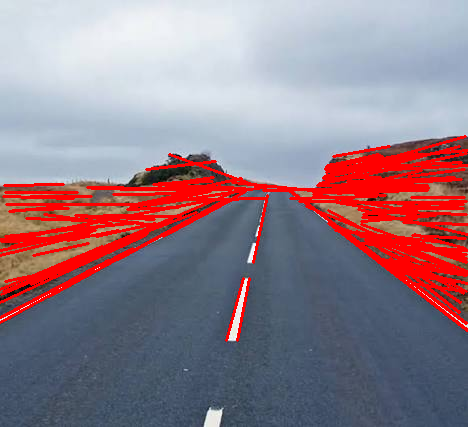

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

img = cv2.imread('/content/Road.jpg')

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

edges = cv2.Canny(gray, 50, 150)

lines = cv2.HoughLinesP(
    edges,
    1,
    np.pi / 180,
    threshold=50,
    minLineLength=50,
    maxLineGap=10
)

if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(img, (x1, y1), (x2, y2), (0, 0, 255), 2)

cv2_imshow(img)

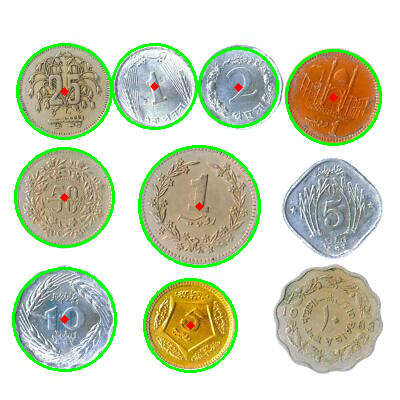

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

img = cv2.imread('/content/Coins.jpg')

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

gray_blurred = cv2.GaussianBlur(gray, (9, 9), 2)

circles = cv2.HoughCircles(
    gray_blurred,
    cv2.HOUGH_GRADIENT,
    dp=1.2,
    minDist=80,
    param1=100,
    param2=45,
    minRadius=35,
    maxRadius=90
)

if circles is not None:
    circles = np.uint16(np.around(circles))
    for circle in circles[0]:
        x, y, r = circle
        cv2.circle(img, (x, y), r, (0, 255, 0), 2)
        cv2.circle(img, (x, y), 2, (0, 0, 255), 3)

cv2_imshow(img)

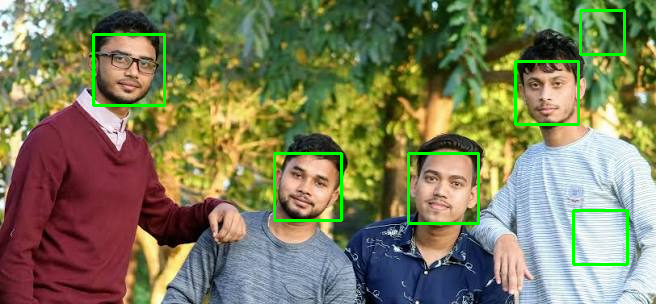

Number of faces detected: 6


In [ ]:
import cv2
from google.colab.patches import cv2_imshow

img = cv2.imread('/content/Faces.jpg')

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(30, 30)
)

for (x, y, w, h) in faces:
    cv2.rectangle(
        img,
        (x, y),
        (x + w, y + h),
        (0, 255, 0),
        2
    )

cv2_imshow(img)

print("Number of faces detected:", len(faces))

<IPython.core.display.Javascript object>

Camera started...
Faces detected: 1


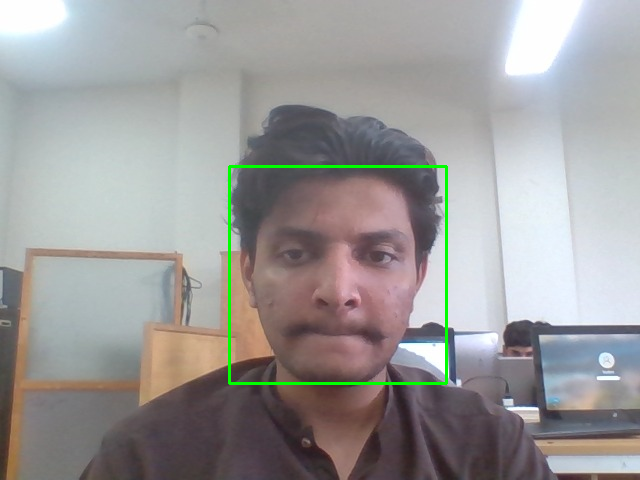

Faces detected: 1


In [ ]:
import cv2
import numpy as np
from google.colab.output import eval_js
from google.colab.patches import cv2_imshow
from IPython.display import display, Javascript
from base64 import b64decode
import time

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

display(Javascript('''
window.startCamera = async function() {

    const video = document.createElement('video');

    video.width = 640;
    video.height = 480;

    document.body.appendChild(video);

    const stream = await navigator.mediaDevices.getUserMedia({
        video: true
    });

    video.srcObject = stream;

    await video.play();

    window.video = video;
    window.stream = stream;
};

window.takePhoto = function() {

    const canvas = document.createElement('canvas');

    canvas.width = window.video.videoWidth;
    canvas.height = window.video.videoHeight;

    canvas.getContext('2d').drawImage(
        window.video,
        0,
        0
    );

    return canvas.toDataURL('image/jpeg');
};

window.stopCamera = function() {

    if (window.stream) {
        window.stream.getTracks().forEach(
            track => track.stop()
        );
    }

    if (window.video) {
        window.video.remove();
    }
};
'''))

eval_js('startCamera()')

print("Camera started...")
time.sleep(2)

for i in range(10):

    data = eval_js('takePhoto()')

    binary = b64decode(data.split(',')[1])

    img = cv2.imdecode(
        np.frombuffer(binary, np.uint8),
        cv2.IMREAD_COLOR
    )

    gray = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2GRAY
    )

    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(30, 30)
    )

    for (x, y, w, h) in faces:

        cv2.rectangle(
            img,
            (x, y),
            (x + w, y + h),
            (0, 255, 0),
            2
        )

    print("Faces detected:", len(faces))

    cv2_imshow(img)

    time.sleep(0.5)

eval_js('stopCamera()')